### Decision Stumps

The following code creates a Decision Stump classifier, and then uses it to train a model using the data set in the file 'M1_data1_heart.csv'. 

The goal is to find out which feature gives lowest training and test error rates. So we create a decision stump classifier for each feature, calculate its training and test error rates, and store it in a dictionary. After going through each feature, we plot the training and testing error rates for all features. 

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Create a class DecisionStumpClassifier

In [112]:
class DecisionStumpClassifier:

    #Each call to train() learns the prediction for one unique feature_value
    #label = the most common class for a feature_value
    #stumpValue stores (feature-value, most common class)
    def train(self, feature, feature_value, label): 
        if not hasattr(self, 'stumpValues'):
            self.stumpValues = {}
        self.stumpValues[feature_value] = label

    #predict returns an array of predictions by looking up stumpValues for unique feature_values
    def predict(self, feature_values):
        yhat = []
        for value in feature_values:
            yhat.append(self.stumpValues[value])
        return np.array(yhat)

    #loss_01 is the 0-1 loss function L(y,yhat) 
    #L(y, yhat) = 0 if y = yhat
    #L(y, yhat) = 1 if y != yhat
    def loss_01(self, labels, feature_values):
        yhat = self.predict(feature_values)
        loss = np.mean(yhat != labels)
        return loss


#### Load dataset

In [113]:
data_file = 'M1_data1_heart.csv'
df = pd.read_csv(data_file, index_col=0)
split = 0.8 #80-20 split for train and test
split_index = int(df.count().values[0] * split) # calculate index at which to split the data

train_set = df.iloc[:split_index, :]
test_set = df.iloc[split_index:, :]

print(train_set.head())

   sex  chest_pain  high_blood_sugar  abnormal_ecg  angina  flat_ST  \
0    0           0                 0             1       1        0   
1    1           1                 0             0       0        0   
2    1           0                 0             1       1        1   
3    0           1                 0             0       0        0   
4    1           0                 1             0       0        0   

   fluoroscopy  thalassemia  heart_disease  
0            1            1              1  
1            1            1              1  
2            0            1              1  
3            0            0              0  
4            1            1              1  


#### Separate features and labels

In [114]:
X_train = train_set.drop(columns=['heart_disease'])
y_train = train_set['heart_disease']

X_test = test_set.drop(columns = ['heart_disease'])
y_test = test_set['heart_disease']


#### Get features and create dictionaries to hold error rates for each feature

In [115]:
feature_columns = X_train.columns

test_errors = {}
train_errors = {}

#### Train decision stumps for each feature and calculate training and test errors

In [116]:
for feature in feature_columns:
    stump = DecisionStumpClassifier()
    for value in X_train[feature].unique():
        labels = y_train[X_train[feature] == value] #get all labels for this feature-value
        majority = labels.mode()[0]
        stump.train(feature, value, majority)

    #compute test and training error
    test_error = stump.loss_01(y_test, X_test[feature])
    train_error = stump.loss_01(y_train, X_train[feature])

    #store errors in dictionaries with key as feature
    test_errors[feature] = test_error
    train_errors[feature] = train_error

In [117]:
print(test_errors, train_errors)

{'sex': 0.375, 'chest_pain': 0.2, 'high_blood_sugar': 0.525, 'abnormal_ecg': 0.35, 'angina': 0.3, 'flat_ST': 0.25, 'fluoroscopy': 0.275, 'thalassemia': 0.225} {'sex': 0.3625, 'chest_pain': 0.25, 'high_blood_sugar': 0.48125, 'abnormal_ecg': 0.43125, 'angina': 0.29375, 'flat_ST': 0.33125, 'fluoroscopy': 0.2625, 'thalassemia': 0.2125}


#### Plot barcharts

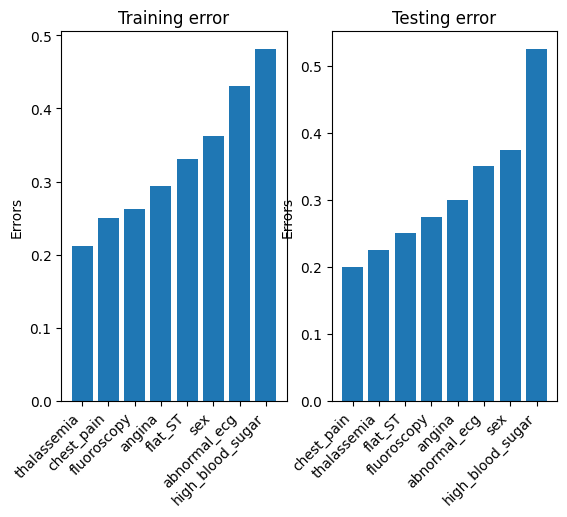

In [118]:
fig, (ax1, ax2) = plt.subplots(1, 2)

#sort the training errors
sorted_train_errors = sorted(train_errors.items(), key=lambda item: item[1])
keys = [item[0] for item in sorted_train_errors]
values = [item[1] for item in sorted_train_errors]

#setup the plot for training errors
ax1.bar(keys, values, label=feature_columns)
ax1.set_ylabel('Errors')
ax1.set_title('Training error')

#sort the testing errors
sorted_test_errors = sorted(test_errors.items(), key=lambda item: item[1])
keys = [item[0] for item in sorted_test_errors]
values = [item[1] for item in sorted_test_errors]

#setup the plot for testing errors
ax2.bar(keys, values, label=feature_columns)
ax2.set_ylabel('Errors')
ax2.set_title('Testing error')

#align the x-axis labels
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

plt.show()